# Model Training

Training and comparing a Random Forest and Logistic Regression classifier on the synthetic cat behavior dataset. Includes hyperparameter tuning via GridSearchCV and comparison against the EDA baseline. 

**Baseline from Week 1 cross-validation:** 0.839 ± 0.010

In [1]:
import sys
sys.path.insert(0, "../..")

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.data.preprocess import load_and_clean, encode_features, get_feature_names
from src.models.train import train_models, tune_random_forest, save_model
from src.models.evaluate import evaluate_model, plot_feature_importance

from pathlib import Path
data_path = Path.cwd()
if data_path.name == "notebooks":
    data_path = data_path.parent

df = load_and_clean(path=str(data_path / "data" / "processed" / "cat_behavior_clean.csv"))
X, y, cat_enc, label_enc = encode_features(df)
label_names = label_enc.classes_.tolist()
feature_names = get_feature_names()

print(f"X shape: {X.shape}")
print(f"Labels: {label_names}")

X shape: (1996, 5)
Labels: ['anxious', 'grumpy', 'happy', 'playful', 'sleepy']


## Baseline Models

Training both models with default hyperparameters first to establish a baseline before tuning.

In [2]:
results = train_models(X, y)
rf = results["random_forest"]
lr = results["logistic_regression"]
X_train, X_test, y_train, y_test = results["splits"]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"RF test accuracy: {rf.score(X_test, y_test):.3f}")
print(f"LR test accuracy: {lr.score(X_test, y_test):.3f}")

Train size: 1596 | Test size: 400
RF test accuracy: 0.843
LR test accuracy: 0.767


## Random Forest - Confusion Matrix & Feature Importance


Random Forest
              precision    recall  f1-score   support

     anxious       0.83      0.82      0.83        85
      grumpy       0.88      0.87      0.87        82
       happy       0.94      0.93      0.93        82
     playful       0.77      0.82      0.80        80
      sleepy       0.79      0.76      0.78        71

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400



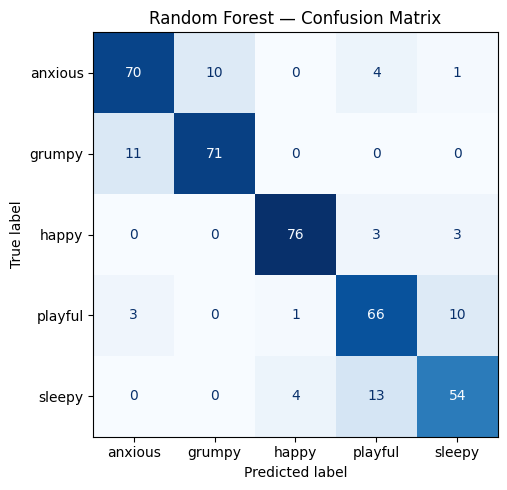

In [3]:
fig_cm_rf, y_pred_rf = evaluate_model(rf, X_test, y_test, label_names, "Random Forest")
plt.show()

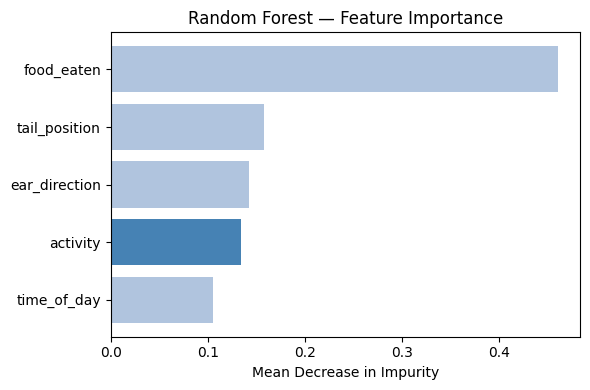

In [4]:
fig_fi = plot_feature_importance(rf, feature_names)
plt.show()

## Logistic Regression - Confusion Matrix


Logistic Regression
              precision    recall  f1-score   support

     anxious       0.66      0.71      0.68        85
      grumpy       0.80      0.74      0.77        82
       happy       0.88      0.88      0.88        82
     playful       0.74      0.76      0.75        80
      sleepy       0.77      0.75      0.76        71

    accuracy                           0.77       400
   macro avg       0.77      0.77      0.77       400
weighted avg       0.77      0.77      0.77       400



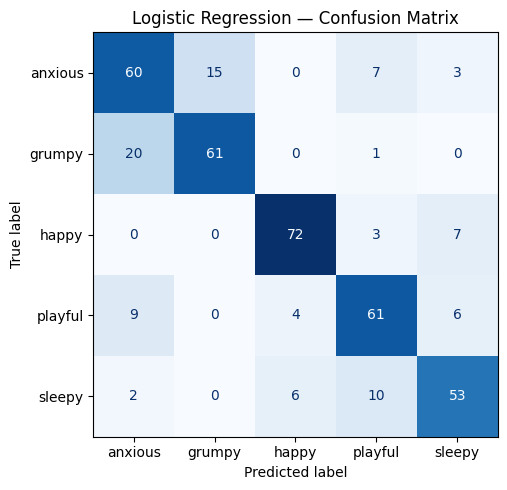

In [5]:
fig_cm_lr, y_pred_lr = evaluate_model(lr, X_test, y_test, label_names, "Logistic Regression")
plt.show()

## Hyperparameter Tuning - Random Forest

GridSearchCV over 'n_estimators', 'max_depth', and 'min_samples_split'.

In [6]:
rf_tuned = tune_random_forest(X_train, y_train)
print(f"\nTuned RF test accuracy: {rf_tuned.score(X_test, y_test):.3f}")

Best RF params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Best CV score:  0.845

Tuned RF test accuracy: 0.845


## Model Comparison

In [7]:
comparison = pd.DataFrame({
    "Model": ["Random Forest (baseline)", "Logistic Regression", "Random Forest (tuned)"], 
    "Test Accuracy": [
        round(rf.score(X_test, y_test), 3),
        round(lr.score(X_test, y_test), 3),
        round(rf_tuned.score(X_test, y_test), 3),
    ]
})
comparison

,Model,Test Accuracy
0,Random Forest (baseline),0.843
1,Logistic Regression,0.767
2,Random Forest (tuned),0.845


## Save Models

In [8]:
models_path = data_path / "artifacts" / "models" 
models_path.mkdir(parents=True, exist_ok=True)

save_model(rf_tuned, str(models_path / "rf_model.pkl"))
save_model(lr, str(models_path / "logreg_model.pkl"))
save_model(cat_enc, str(models_path / "cat_encoder.pkl"))
save_model(label_enc, str(models_path / "label_encoder.pkl"))

Saved → /Users/melcadd/PycharmProjects/ai-cat-companion/artifacts/models/rf_model.pkl
Saved → /Users/melcadd/PycharmProjects/ai-cat-companion/artifacts/models/logreg_model.pkl
Saved → /Users/melcadd/PycharmProjects/ai-cat-companion/artifacts/models/cat_encoder.pkl
Saved → /Users/melcadd/PycharmProjects/ai-cat-companion/artifacts/models/label_encoder.pkl


## Key Findings

### Model Performance Summary
| Model | Test Accuracy | vs. CV Baseline (0.839) |
|---|---|---|
| Random Forest (baseline) | 0.843 | +0.004 |
| Logistic Regression | 0.767 | -0.072 |

RF generalizes well - test accuracy is within 0.004 of the cross-validation baseline, confirming no overfitting. LR trails by 7.6 points, expected given the non-linear decision boundaries in this dataset.

### Feature Importance (Random Forest) 
'food_eaten' is the dominant feature at ~0.46 importance - more than 3x the contribution of any other feature. This confirms the EDA hypothesis that food intake is the clearest mood signal in the dataset.

Ranking: 'food_eaten' >> 'tail_position' (~0.16) 
≈ 'ear_direction' (~0.14)
≈ 'activity' (~0.13) > 'time_of_day' (~0.10)

Notably, 'activity' - predicted in EDA to be a co-dominant feature alongside 'food_eaten' - ranked 4th. 'tail_position' and 'ear_direction' carry more signal than expected, likely because they are tightly coupled in 'MOOD_RULES'.

'time_of_day' is the weakest feature as predicted, but contributes non-zero signal (~0.10) - the RF is extracting marginal information even from a feature with no direct rule bias. 

### Per-Class Performance (Random Forest)
| Mood | F1-Score | Notes |
|---|---|---|
| 'happy' | 0.93 | Easiest to classify - 'food_eaten' range [0.6-1.0] is uniquely high |
| 'grumpy' | 0.87 | Well separated despite low-food overlap with 'anxious' |
| 'anxious' | 0.83 | Hardest after 'sleepy' - shares hiding/low-food profile with 'grumpy' |
| 'playful' | 0.80 | Moderate confusion with 'anxious' and 'sleepy' |
| 'sleepy' | 0.78 | Lowest F1 - food range [0.4-0.8] overlaps 'playful' and 'happy' |

### Where Logistic Regression Fails
The LR confusion matrix reveals its core weakness: the 'anxious'/'grumpy' boundary. 15 'anxious' smaples are misclassified as 'grumpy' and 20 'grumpy' samples as 'anxious' - a bidirectional confusion the RF handles more cleanly. 
This is a non-linear boundary that LR's linear decision surface cannot resolve, confirming the EDA hypothesis. 

'happy' remains the easiest class for LR (F1 0.88) for the same reason as RF - 'food_eaten' creates a nearly linearly separable threshold. 

### Implications for Phase 3 (RL Agent)
- The 16% RF error rate is concentrated in 'anxious'/'grumpy'/'sleepy' confusions - this is where user corrections will be most frequent and where the RL agent has the most room to improve
- 'food_eaten' dominance means the agent should pay close attention to corrections on low-food samples where 'anxious' vs 'grumpy' is ambiguous
- Tuning target: push RF accuracy above 0.87 through learned corrections